Using device: cpu
Classes found: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total images: 4317
Starting training...

Epoch [1/15] - Loss: 0.5423 - Accuracy: 80.26%
Epoch [2/15] - Loss: 0.1780 - Accuracy: 94.23%
Epoch [3/15] - Loss: 0.0909 - Accuracy: 97.24%
Epoch [4/15] - Loss: 0.0847 - Accuracy: 97.36%
Epoch [5/15] - Loss: 0.0533 - Accuracy: 98.38%
Epoch [6/15] - Loss: 0.0629 - Accuracy: 97.92%
Epoch [7/15] - Loss: 0.0457 - Accuracy: 98.63%
Epoch [8/15] - Loss: 0.0506 - Accuracy: 98.26%
Epoch [9/15] - Loss: 0.0496 - Accuracy: 98.26%
Epoch [10/15] - Loss: 0.0583 - Accuracy: 98.12%
Epoch [11/15] - Loss: 0.0380 - Accuracy: 98.56%
Epoch [12/15] - Loss: 0.0331 - Accuracy: 98.86%
Epoch [13/15] - Loss: 0.0283 - Accuracy: 99.05%
Epoch [14/15] - Loss: 0.0266 - Accuracy: 98.98%
Epoch [15/15] - Loss: 0.0244 - Accuracy: 99.19%

Training complete!
Model saved to models/flower_resnet18.pth


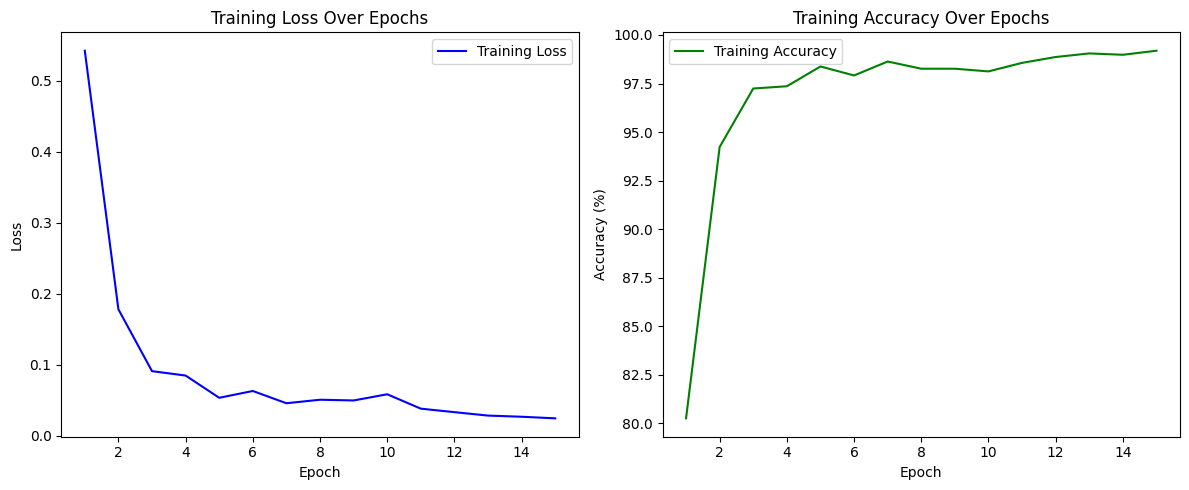

In [1]:
# %% [markdown]
# # Flower Classification with Pretrained ResNet18
# Train a ResNet18 model on flower dataset located at `D:\ml_lern\dataset`
# and visualize training loss and accuracy.

# %%
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# %%
# ==== CONFIGURATION ====
data_dir = r"D:\ml_lern\dataset"  # Update this to your dataset path
batch_size = 16
image_size = 128
epochs = 15
learning_rate = 0.0001
model_save_path = "models/flower_resnet18.pth"

# %%
# ==== DEVICE SETUP ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# %%
# ==== DATA TRANSFORMS ====
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet normalization
                         std=[0.229, 0.224, 0.225])
])

# %%
# ==== LOAD DATASET ====
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

class_names = dataset.classes
num_classes = len(class_names)

print(f"Classes found: {class_names}")
print(f"Total images: {len(dataset)}")

# %%
# ==== MODEL SETUP ====
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, num_classes)  # Replace final layer
model = model.to(device)

# %%
# ==== LOSS AND OPTIMIZER ====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# %%
# ==== TRAINING LOOP ====
train_losses = []
train_accuracies = []

print("Starting training...\n")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

print("\nTraining complete!")

# %%
# ==== SAVE MODEL ====
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

# %%
# ==== PLOT TRAINING LOSS AND ACCURACY ====
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, label='Training Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()


Using device: cpu
Classes found: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total images: 4317
Starting training...

Epoch [1/15] - Loss: 0.5354 - Accuracy: 79.73%
Epoch [2/15] - Loss: 0.1755 - Accuracy: 94.16%
Epoch [3/15] - Loss: 0.1158 - Accuracy: 96.43%
Epoch [4/15] - Loss: 0.0696 - Accuracy: 97.87%
Epoch [5/15] - Loss: 0.0534 - Accuracy: 98.31%
Epoch [6/15] - Loss: 0.0609 - Accuracy: 97.82%
Epoch [7/15] - Loss: 0.0510 - Accuracy: 98.49%
Epoch [8/15] - Loss: 0.0475 - Accuracy: 98.47%
Epoch [9/15] - Loss: 0.0433 - Accuracy: 98.75%
Epoch [10/15] - Loss: 0.0388 - Accuracy: 98.77%
Epoch [11/15] - Loss: 0.0425 - Accuracy: 98.47%
Epoch [12/15] - Loss: 0.0397 - Accuracy: 98.59%
Epoch [13/15] - Loss: 0.0301 - Accuracy: 99.10%
Epoch [14/15] - Loss: 0.0310 - Accuracy: 98.89%
Epoch [15/15] - Loss: 0.0489 - Accuracy: 98.36%

Training complete!
Model saved to models/flower_resnet18.pth


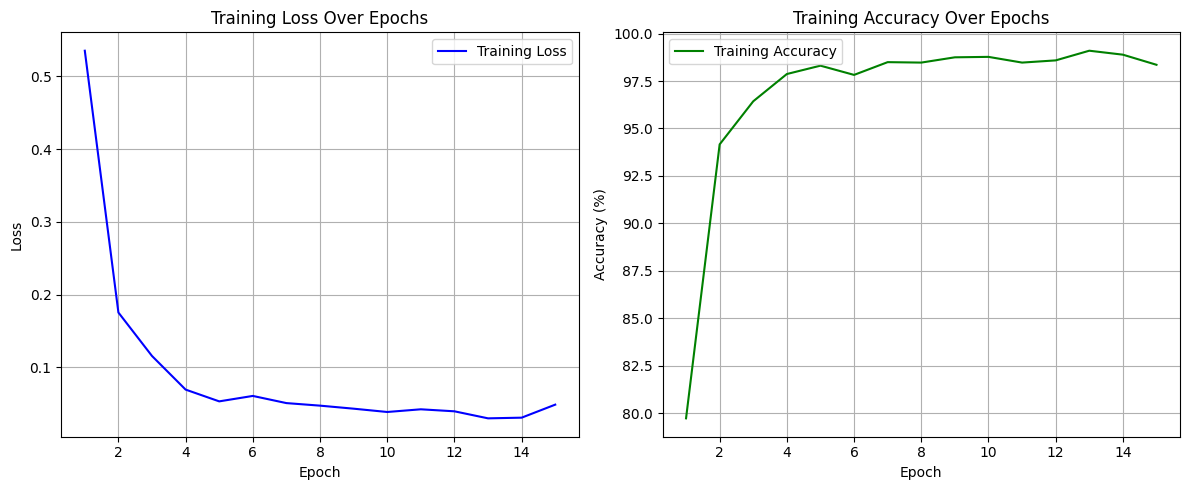

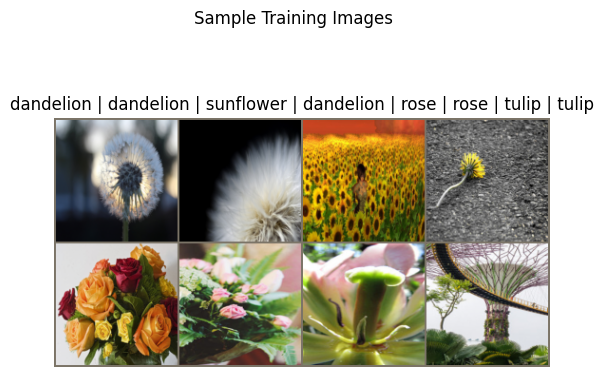

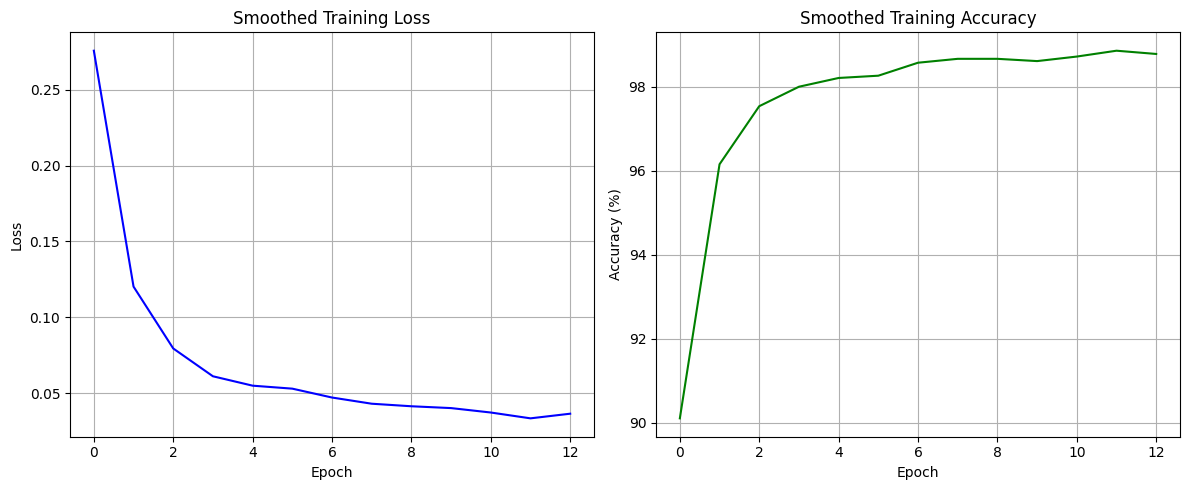

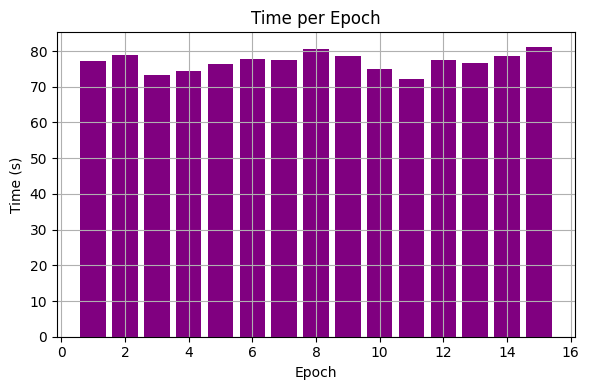

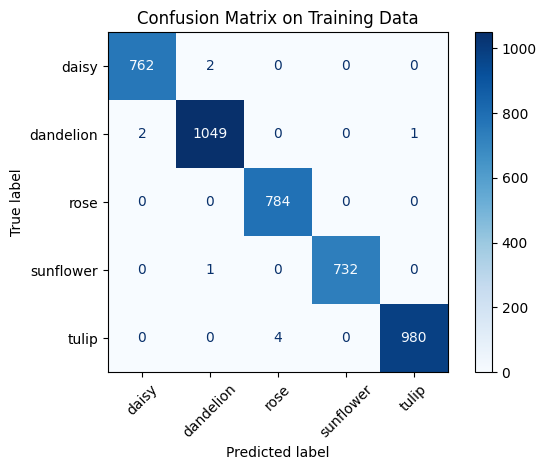

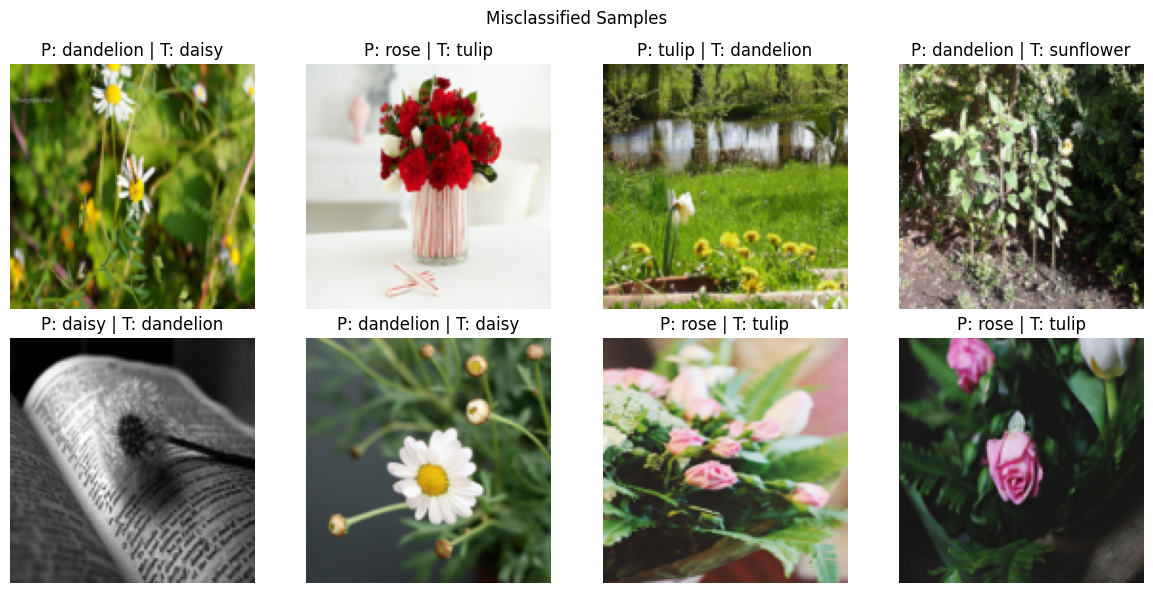

In [12]:
# %% [markdown]
# # Flower Classification with ResNet18 and Enhanced Visualizations

# %%
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torchvision

# ==== CONFIGURATION ====
data_dir = r"D:\ml_lern\dataset"  # Update this
batch_size = 16
image_size = 128
epochs = 15
learning_rate = 0.0001
model_save_path = "models/flower_resnet18.pth"

# ==== DEVICE SETUP ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==== DATA TRANSFORMS ====
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ==== LOAD DATASET ====
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
class_names = dataset.classes
num_classes = len(class_names)
print(f"Classes found: {class_names}")
print(f"Total images: {len(dataset)}")

# ==== MODEL SETUP ====
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ==== LOSS AND OPTIMIZER ====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ==== TRAINING LOOP ====
train_losses = []
train_accuracies = []
epoch_times = []

print("Starting training...\n")
for epoch in range(epochs):
    model.train()
    start_time = time.time()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    end_time = time.time()

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    epoch_times.append(end_time - start_time)

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

print("\nTraining complete!")

# ==== SAVE MODEL ====
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

# %% [markdown]
# ## 1. Plot Training Loss and Accuracy

# %%
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, label='Training Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy Over Epochs')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 2. Show Sample Images

# %%
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')

# %%
images, labels = next(iter(dataloader))
out = torchvision.utils.make_grid(images[:8], nrow=4)
imshow(out, title=" | ".join([class_names[labels[i]] for i in range(8)]))
plt.suptitle("Sample Training Images")
plt.show()

# %% [markdown]
# ## 3. Smoothed Curves

# %%
def smooth(values, window=3):
    return np.convolve(values, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(smooth(train_losses), label='Smoothed Loss', color='blue')
plt.title('Smoothed Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(smooth(train_accuracies), label='Smoothed Accuracy', color='green')
plt.title('Smoothed Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid()

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 4. Epoch Training Time

# %%
plt.figure(figsize=(6, 4))
plt.bar(range(1, epochs+1), epoch_times, color='purple')
plt.xlabel('Epoch')
plt.ylabel('Time (s)')
plt.title('Time per Epoch')
plt.grid(True)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5. Confusion Matrix

# %%
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix on Training Data")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 6. Misclassified Samples

# %%
wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        for i in range(len(images)):
            if preds[i] != labels[i]:
                wrong_images.append(images[i].cpu())
                wrong_preds.append(preds[i].cpu())
                wrong_labels.append(labels[i])
            if len(wrong_images) >= 8:
                break
        if len(wrong_images) >= 8:
            break

# Display misclassified
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow(wrong_images[i], title=f"P: {class_names[wrong_preds[i]]} | T: {class_names[wrong_labels[i]]}")
plt.suptitle("Misclassified Samples")
plt.tight_layout()
plt.show()


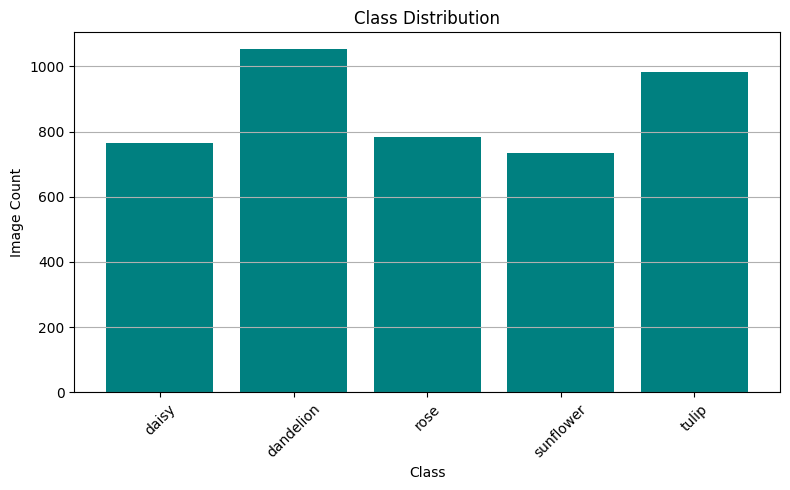

In [5]:
# %% [markdown]
# ## Class Distribution

# %%
from collections import Counter

labels_list = [label for _, label in dataset.samples]
class_counts = Counter(labels_list)

plt.figure(figsize=(8, 5))
plt.bar(class_names, [class_counts[i] for i in range(len(class_names))], color='teal')
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.011764707922935491..1.1803921650648117].


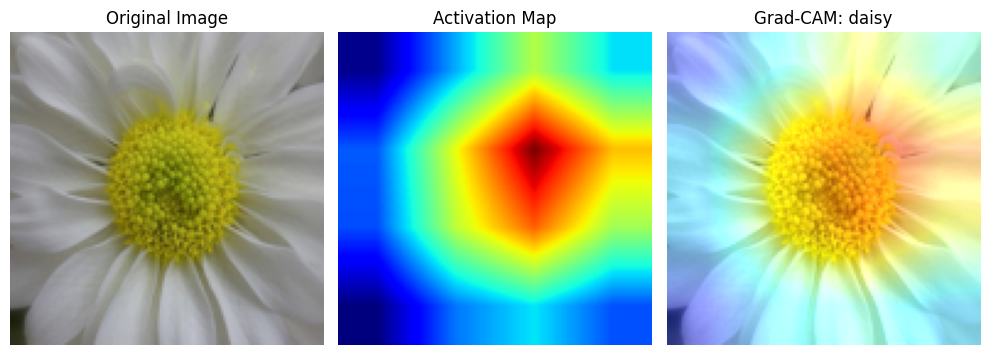

In [6]:
# %% [markdown]
# ## Grad-CAM for Class Activation

# %%
import cv2
import torchvision.transforms.functional as F

def show_gradcam(model, image_tensor, label, class_names):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Hook the gradients
    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    # Register hooks
    final_conv = model.layer4[-1].conv2
    handle_fw = final_conv.register_forward_hook(forward_hook)
    handle_bw = final_conv.register_backward_hook(backward_hook)

    # Forward pass
    output = model(image_tensor)
    class_idx = torch.argmax(output, dim=1).item()

    # Backward pass
    model.zero_grad()
    loss = output[0, class_idx]
    loss.backward()

    grads = gradients[0].cpu().detach().numpy()[0]
    acts = activations[0].cpu().detach().numpy()[0]

    weights = np.mean(grads, axis=(1, 2))  # global average pooling
    cam = np.zeros(acts.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam, 0)
    cam = cam / cam.max()
    cam = cv2.resize(cam, (image_size, image_size))
    
    # Convert tensor to image
    img_np = image_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    img_np = np.clip(img_np * np.array([0.229, 0.224, 0.225]) + 
                     np.array([0.485, 0.456, 0.406]), 0, 1)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    superimposed_img = heatmap * 0.4 + img_np

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap='jet')
    plt.title("Activation Map")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM: {class_names[class_idx]}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Remove hooks
    handle_fw.remove()
    handle_bw.remove()

# Run Grad-CAM on one sample
sample_img, sample_label = dataset[0]
show_gradcam(model, sample_img, sample_label, class_names)


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.011764707922935491..1.1803921650648117].




== Grad-CAM for Class: daisy ==

Sample 1


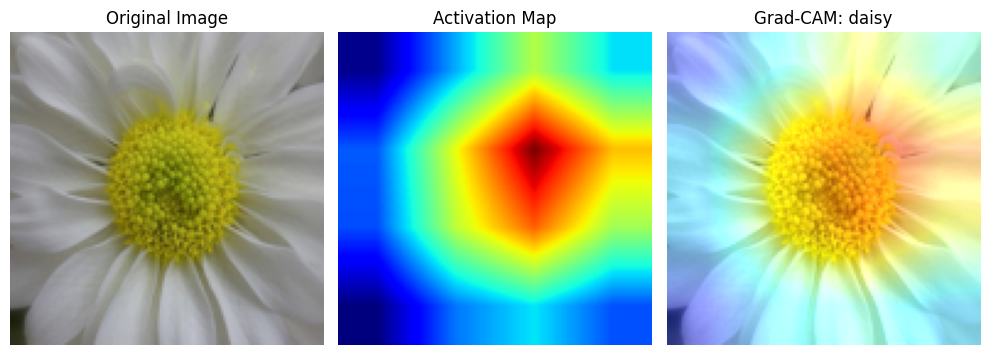

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.011764707922935491..1.3686274585723877].



Sample 2


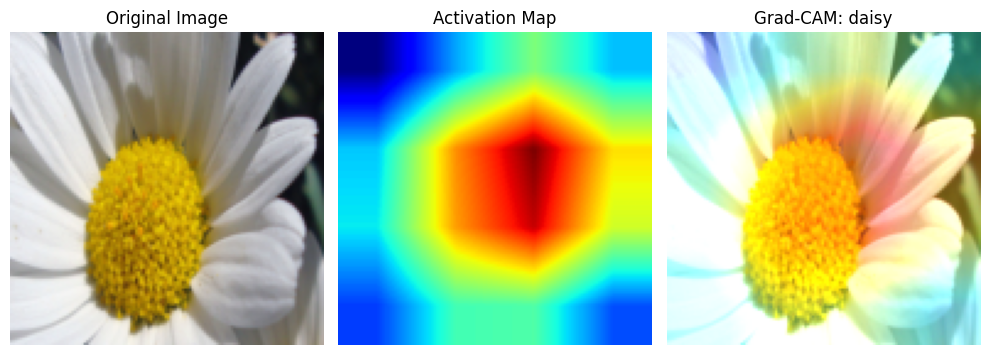

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.027450992584228506..1.3764705595970153].



Sample 3


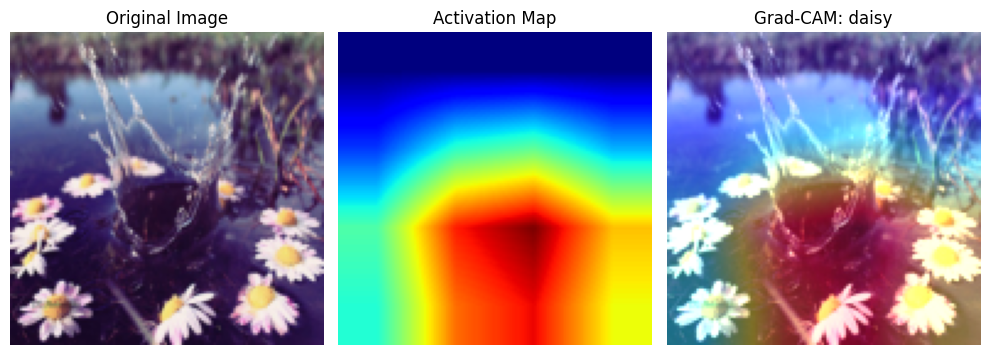

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.027450992584228506..1.2298039021749123].



Sample 4


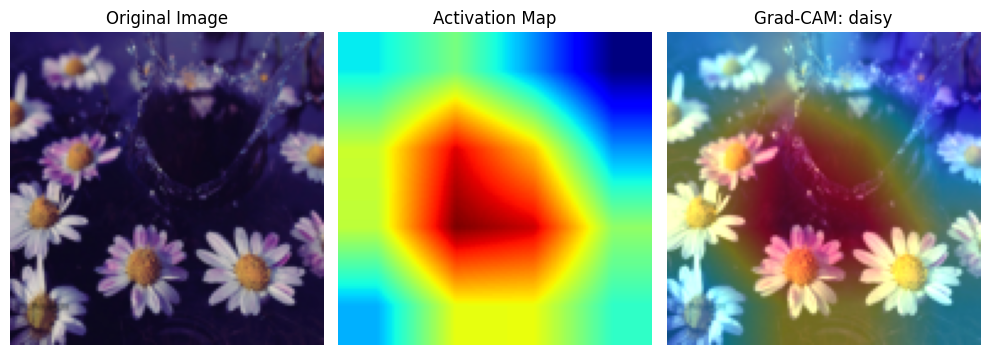

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.04705883789062498..1.0784313813447952].



Sample 5


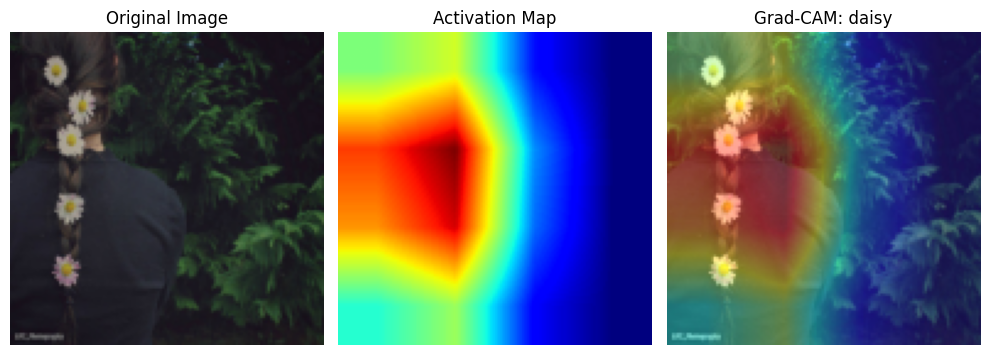

In [11]:
# %% [markdown]
# ## Grad-CAM for Class Activation

# %% Imports
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import torchvision.transforms.functional as F

# %% Grad-CAM Function
def show_gradcam(model, image_tensor, label, class_names):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Hook the gradients
    gradients = []
    activations = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    # Register hooks
    final_conv = model.layer4[-1].conv2  # for ResNet-like models
    handle_fw = final_conv.register_forward_hook(forward_hook)
    handle_bw = final_conv.register_backward_hook(backward_hook)

    # Forward pass
    output = model(image_tensor)
    class_idx = torch.argmax(output, dim=1).item()

    # Backward pass
    model.zero_grad()
    loss = output[0, class_idx]
    loss.backward()

    grads = gradients[0].cpu().detach().numpy()[0]
    acts = activations[0].cpu().detach().numpy()[0]

    weights = np.mean(grads, axis=(1, 2))  # global average pooling
    cam = np.zeros(acts.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam, 0)
    cam = cam / cam.max()
    cam = cv2.resize(cam, (image_size, image_size))
    
    # Convert tensor to image
    img_np = image_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    img_np = np.clip(img_np * np.array([0.229, 0.224, 0.225]) + 
                     np.array([0.485, 0.456, 0.406]), 0, 1)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    superimposed_img = heatmap * 0.4 + img_np

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap='jet')
    plt.title("Activation Map")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM: {class_names[class_idx]}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Remove hooks
    handle_fw.remove()
    handle_bw.remove()

# %% Collect 5 samples per class and run Grad-CAM
samples_per_class = defaultdict(list)
num_samples = 5  # Number per class

# Loop through the dataset to collect samples
for img, label in dataset:
    if len(samples_per_class[label]) < num_samples:
        samples_per_class[label].append(img)
    if all(len(v) >= num_samples for v in samples_per_class.values()):
        break

# %% Run Grad-CAM on collected samples
for label, images in samples_per_class.items():
    print(f"\n\n== Grad-CAM for Class: {class_names[label]} ==")
    for i, img in enumerate(images):
        print(f"\nSample {i+1}")
        show_gradcam(model, img, label, class_names)


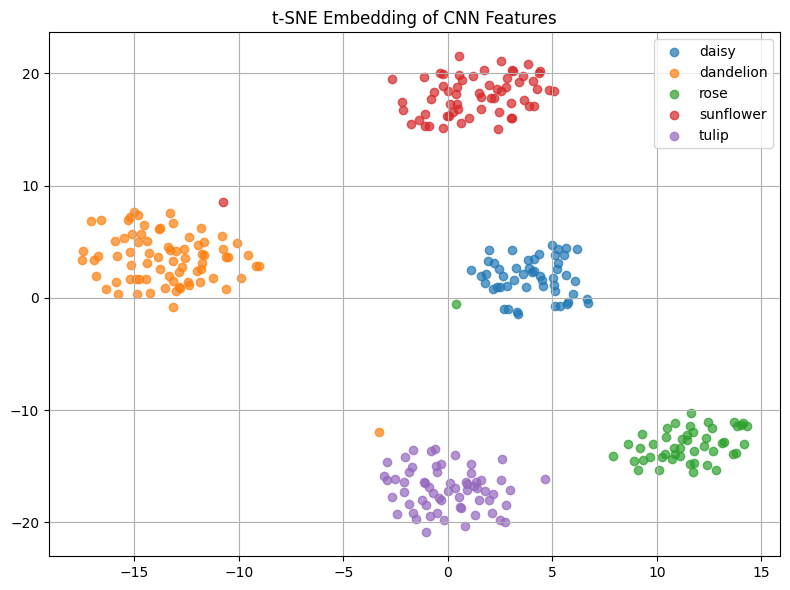

In [10]:
# %% [markdown]
# ## t-SNE Embedding of CNN Features (Corrected)

# %%
from sklearn.manifold import TSNE

features = []
labels_tsne = []

# Function to extract features (before fc)
def extract_features(model, x):
    x = model.conv1(x)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)

    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.layer4(x)

    x = model.avgpool(x)  # shape: [B, 512, 1, 1]
    x = torch.flatten(x, 1)  # shape: [B, 512]
    return x

# Limit number of samples
max_samples = 300

model.eval()
with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)
        feats = extract_features(model, images)  # shape [B, 512]
        features.append(feats.cpu().numpy())
        labels_tsne.extend(labels.numpy())

        if len(labels_tsne) >= max_samples:
            break

features = np.vstack(features)[:max_samples]
labels_tsne = labels_tsne[:max_samples]

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(features)

# Plot
plt.figure(figsize=(8, 6))
for idx, cls in enumerate(class_names):
    points = tsne_result[np.array(labels_tsne) == idx]
    plt.scatter(points[:, 0], points[:, 1], label=cls, alpha=0.7)
plt.legend()
plt.title("t-SNE Embedding of CNN Features")
plt.grid(True)
plt.tight_layout()
plt.show()


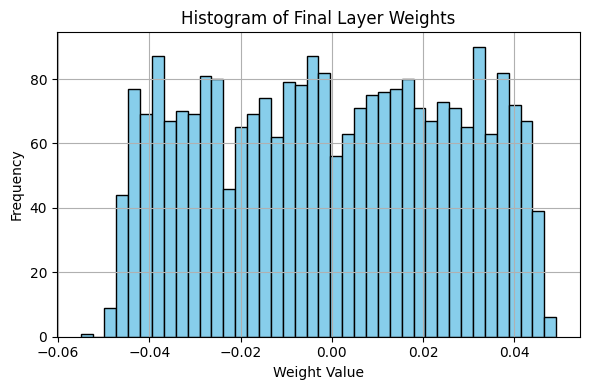

In [8]:
# %% [markdown]
# ## Model Weight Distribution

# %%
weights = model.fc.weight.data.cpu().numpy().flatten()

plt.figure(figsize=(6, 4))
plt.hist(weights, bins=40, color='skyblue', edgecolor='black')
plt.title("Histogram of Final Layer Weights")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


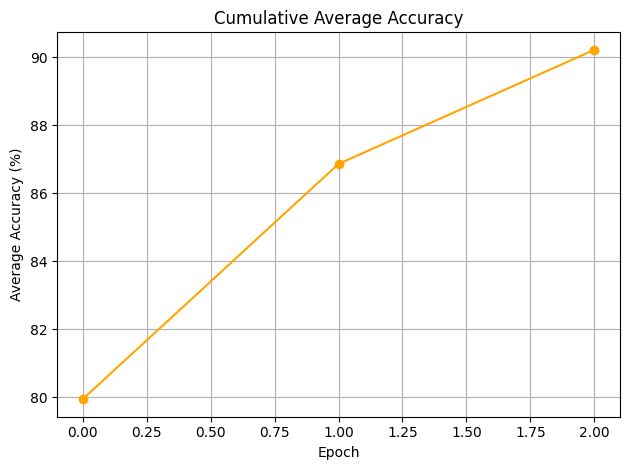

In [9]:
# %% [markdown]
# ## Cumulative Accuracy Curve

# %%
plt.plot(np.cumsum(train_accuracies) / np.arange(1, len(train_accuracies)+1), marker='o', color='orange')
plt.title("Cumulative Average Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Average Accuracy (%)")
plt.grid(True)
plt.tight_layout()
plt.show()
